# LLM01 — mini BERT 만들기 (Pretrain)

AIFFEL LMS `BERT_pretrained_model[프로젝트]_제작` 의 **프로젝트: mini BERT 만들기** 제출용 노트북입니다.

## 루브릭 대응
1. 한글 코퍼스로 BERT pretrain 데이터셋(MLM+NSP) 생성
2. MLM/NSP loss가 안정적으로 감소하는지 확인
3. 파라미터 약 **1M** 수준의 mini BERT를 학습하고, 모델·학습 곡선 제출

## Colab 실행 안내
1. 런타임 → **GPU (T4 등)** 권장
2. 위에서부터 **순서대로** 실행
3. `USE_DRIVE=True` 이면 생성 산출물 전부 `MyDrive/AIFFEL/LLM01` 로 자동 백업·복원

### GPU가 CPU로 바뀌는 경우
- `ensure_gpu()` + `REQUIRE_GPU=True` → GPU 아니면 즉시 중단
- 에폭마다 ckpt + **RESUME** → 끊겨도 이어서 학습
- Drive에 tokenizer / json / memmap / ckpt / 그래프까지 동기화


## 0. 환경 준비 (Colab)

GPU 런타임을 확인하고, Colab에서 만들어지는 파일은 Drive에 자동 백업되도록 설정합니다.
세션이 초기화되어도 Drive에 있으면 `/content`로 복원한 뒤 재학습을 건너뜁니다.


In [1]:
# Colab 패키지
!pip -q install sentencepiece tqdm torchinfo

import sys
print("python:", sys.version.split()[0])


python: 3.12.13


In [2]:
# =============================================================================
# 0) imports + Colab 경로 + GPU 가드 + Google Drive 자동 동기화
# =============================================================================
# 이 셀이 하는 일:
#   1. 재현성을 위해 seed 고정
#   2. /content/data, /content/models 작업 디렉터리 생성
#   3. CUDA(GPU) 사용 가능 여부 엄격 검사 (REQUIRE_GPU)
#   4. Google Drive 마운트 후, 기존 산출물 복원 + 이후 생성물 자동 백업
# =============================================================================
from __future__ import annotations

import math
import random
import json
import zipfile
import urllib.request
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import sentencepiece as spm
from tqdm.notebook import tqdm

# ----- 재현성: 데이터 샘플링 / 가중치 초기화 / Dropout 경로를 고정 -----
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Colab ephemeral 스토리지 (세션 종료 시 사라짐 → Drive 백업 필수)
DATA_DIR = Path("/content/data")
MODEL_DIR = Path("/content/models")
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# REQUIRE_GPU=True  : GPU가 아니면 assert로 중단 (CPU로 장시간 돌리는 사고 방지)
# USE_DRIVE=True    : 생성 파일을 Drive에 자동 백업 / 시작 시 복원
REQUIRE_GPU = True
USE_DRIVE = True


def ensure_gpu(stage: str = ""):
    """중요 단계 직전에 CUDA 사용 가능 여부를 재확인합니다.

    Colab은 유휴/할당 변경으로 GPU→CPU 전환이 가능합니다.
    학습 루프에서 epoch마다 호출해 '조용히 CPU로 계속 도는' 상황을 막습니다.
    """
    ok = torch.cuda.is_available()
    name = torch.cuda.get_device_name(0) if ok else "CPU only"
    print(f"[GPU check{(' @ ' + stage) if stage else ''}] cuda_available={ok} → {name}")
    if REQUIRE_GPU and not ok:
        raise RuntimeError(
            "GPU 런타임이 아닙니다.\n"
            "1) 런타임 → 런타임 유형 변경 → GPU\n"
            "2) 런타임 → 세션 다시 시작\n"
            "3) 이 셀부터 다시 실행하세요.\n"
            "(임시로 CPU만 쓰려면 REQUIRE_GPU=False)"
        )
    return torch.device("cuda" if ok else "cpu")


device = ensure_gpu("init")
print("torch:", torch.__version__)
print("DATA_DIR :", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

DRIVE_DIR = None
if USE_DRIVE:
    try:
        from google.colab import drive

        drive.mount("/content/drive")
        DRIVE_DIR = Path("/content/drive/MyDrive/AIFFEL/LLM01")
        DRIVE_DIR.mkdir(parents=True, exist_ok=True)
        print("Drive sync root:", DRIVE_DIR)
    except Exception as e:
        print("Drive 마운트 실패(로컬 /content 만 사용):", e)
        USE_DRIVE = False


# Colab에서 생성되어 Drive에 보관할 산출물 목록
# (이름만 일치해도 되므로 data/ models 어느 쪽이든 basename으로 동기화)
DRIVE_ARTIFACT_NAMES = [
    # 원본 코퍼스
    "kowiki.txt.zip",
    "kowiki.txt",
    # SentencePiece tokenizer
    "ko_8000.model",
    "ko_8000.vocab",
    # MLM+NSP pretrain 데이터
    "bert_pre_train.json",
    "enc_tokens.memmap",
    "segments.memmap",
    "labels_nsp.memmap",
    "labels_mlm.memmap",
    # 학습 체크포인트 / 시각화 (epoch 파일은 glob로 추가)
    "mini_bert_train_curves.png",
]


def _local_candidates(name: str) -> list[Path]:
    """산출물 이름 → /content 아래 후보 경로 (data 우선, models 다음)."""
    return [DATA_DIR / name, MODEL_DIR / name]


def backup_to_drive(path: Path):
    """단일 파일을 Drive에 즉시 복사합니다. (에폭 종료·파일 생성 직후 호출)"""
    if not USE_DRIVE or DRIVE_DIR is None:
        return
    try:
        if not path.exists() or not path.is_file():
            return
        dest = DRIVE_DIR / path.name
        shutil.copy2(path, dest)
        print("Drive 백업:", dest)
    except Exception as e:
        print("Drive 백업 실패:", path.name, e)


def restore_from_drive(names: list[str] | None = None):
    """Drive에만 있는 산출물을 /content로 복원합니다.

    /content가 비어 있고 Drive에 파일이 있으면 재다운로드·재학습을 건너뛸 수 있습니다.
    """
    if not USE_DRIVE or DRIVE_DIR is None:
        return
    names = names or DRIVE_ARTIFACT_NAMES
    # epoch ckpt도 복원 대상에 포함
    extra = [p.name for p in DRIVE_DIR.glob("mini_bert_epoch_*.pt")]
    for name in list(names) + extra:
        src = DRIVE_DIR / name
        if not src.exists() or not src.is_file():
            continue
        # 확장자로 목적 폴더 결정
        if name.startswith("ko_8000") or name.startswith("mini_bert") or name.endswith(".pt") or name.endswith(".png"):
            dest = MODEL_DIR / name
        else:
            dest = DATA_DIR / name
        if dest.exists() and dest.stat().st_size == src.stat().st_size:
            continue  # 이미 동일 크기면 스킵
        try:
            shutil.copy2(src, dest)
            print(f"Drive→로컬 복원: {name} → {dest}")
        except Exception as e:
            print("복원 실패:", name, e)


def sync_all_to_drive():
    """작업 디렉터리에 있는 알려진 산출물을 일괄 Drive 백업합니다."""
    if not USE_DRIVE or DRIVE_DIR is None:
        return
    # 이름 목록 + epoch ckpt
    names = set(DRIVE_ARTIFACT_NAMES)
    for p in MODEL_DIR.glob("mini_bert_epoch_*.pt"):
        names.add(p.name)
    for name in sorted(names):
        for cand in _local_candidates(name):
            if cand.exists() and cand.is_file():
                backup_to_drive(cand)
                break


# 세션 시작 시 Drive → /content 복원 (이후 셀의 '이미 있음' 스킵 조건이 동작)
restore_from_drive()
print("Drive restore done (missing files only).")


[GPU check @ init] cuda_available=True → Tesla T4
torch: 2.11.0+cu128
DATA_DIR : /content/data
MODEL_DIR: /content/models
Mounted at /content/drive
Drive backup: /content/drive/MyDrive/AIFFEL/LLM01


## 1. Tokenizer 준비 (SentencePiece, vocab=8000)

한글 나무위키 코퍼스에서 **vocab_size=8000** (+ 특수토큰) BPE를 학습합니다.
생성되는 `ko_8000.model` / `.vocab` 은 Drive에 자동 백업됩니다.


In [3]:
# =============================================================================
# 1-A) 한글 나무위키 코퍼스 다운로드
# =============================================================================
# BERT pretrain용 대용량 한국어 텍스트. 이미 /content 또는 Drive에 있으면 재다운로드 안 함.
# =============================================================================
KOWIKI_TXT = DATA_DIR / "kowiki.txt"
KOWIKI_ZIP = DATA_DIR / "kowiki.txt.zip"
KOWIKI_URL = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"

if KOWIKI_TXT.exists():
    print("이미 있음:", KOWIKI_TXT, f"({KOWIKI_TXT.stat().st_size/1e6:.1f} MB)")
else:
    print("다운로드 중...")
    urllib.request.urlretrieve(KOWIKI_URL, KOWIKI_ZIP)
    with zipfile.ZipFile(KOWIKI_ZIP, "r") as zf:
        zf.extractall(DATA_DIR)
    print("완료:", KOWIKI_TXT.exists())

# zip + txt 모두 Drive 백업 (세션 날아도 재다운로드 불필요)
backup_to_drive(KOWIKI_ZIP)
backup_to_drive(KOWIKI_TXT)


다운로드 중...
완료: True


In [4]:
# =============================================================================
# 1-B) SentencePiece BPE 학습 (vocab_size=8000 + 특수토큰 7개)
# =============================================================================
# BERT 특수 토큰: [PAD][UNK][BOS][EOS][SEP][CLS][MASK]
# vocab_size 인자에는 일반 토큰 8000 + 위 특수토큰을 더한 8007을 넣습니다.
# Drive에 ko_8000.model 이 복원되어 있으면 재학습을 건너뜁니다.
# =============================================================================
VOCAB_SIZE = 8000
SPM_PREFIX = MODEL_DIR / "ko_8000"
SPM_MODEL = Path(str(SPM_PREFIX) + ".model")
SPM_VOCAB = Path(str(SPM_PREFIX) + ".vocab")

if SPM_MODEL.exists():
    print("SPM 이미 존재, 재학습 스킵:", SPM_MODEL)
else:
    print("SPM 학습 시작 (시간 소요)...")
    spm.SentencePieceTrainer.train(
        f"--input={KOWIKI_TXT} --model_prefix={SPM_PREFIX} --vocab_size={VOCAB_SIZE + 7} "
        f"--model_type=bpe --max_sentence_length=999999 "
        f"--pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] "
        f"--bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] "
        f"--user_defined_symbols=[SEP],[CLS],[MASK]"
    )
    print("완료:", SPM_MODEL)

# Tokenizer 파일은 이후 pretrain 데이터·재현에 필수 → 즉시 Drive 백업
backup_to_drive(SPM_MODEL)
backup_to_drive(SPM_VOCAB)

vocab = spm.SentencePieceProcessor()
vocab.load(str(SPM_MODEL))
print("n_vocab:", len(vocab))
print("특수토큰:", [vocab.id_to_piece(i) for i in range(7)])
print("예:", vocab.encode_as_pieces("추적추적 비가 내리는 날이었어"))


SPM 학습 시작 (시간 소요)...
완료: /content/models/ko_8000.model
n_vocab: 8007
특수토큰: ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[SEP]', '[CLS]', '[MASK]']
예: ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어']


## 2–4. 데이터 전처리 (MASK / NSP / json + memmap)

- 전체 토큰의 약 **15%** MASK
- 그중 **80% `[MASK]` / 10% 원본 / 10% 랜덤**
- NSP: 연속 문장 50% / 비연속 50%
- `bert_pre_train.json` + memmap 생성 후 **Drive 자동 백업**


In [5]:
# =============================================================================
# 2–4) MASK / NSP / dataset builders
# =============================================================================
# BERT 논문의 pretrain 두 과제:
#   - MLM (Masked Language Model): 토큰 일부(~15%)를 가리고 원래 토큰 예측
#   - NSP (Next Sentence Prediction): 두 문장이 실제로 이어지는지 이진 분류
# 아래 함수들은 LMS 노트북과 동일한 로직을 Colab용으로 정리한 것입니다.
# =============================================================================


def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """띄어쓰기(워드피스 ▁) 단위로 후보를 만들고, 그중 mask_cnt개에 MLM을 적용.

    BERT 80/10/10 규칙:
      - 80%: [MASK] 로 치환 → 모델이 마스크 위치에 집중해서 학습
      - 10%: 원본 유지     → 파인튜닝 시 마스크가 없는 입력에도 일반화
      - 10%: 랜덤 토큰     → 마스크 토큰에만 과적합되지 않도록
    [CLS]/[SEP] 은 절대 마스킹하지 않습니다.
    """
    # ▁로 시작하는 조각이 새 '단어' 시작 → 같은 단어의 subword는 한꺼번에 마스킹
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token in ("[CLS]", "[SEP]"):
            continue
        if 0 < len(cand_idx) and not token.startswith("\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        # 한 단어(=여러 subword)를 통째로 넣었을 때 예산 초과면 스킵
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]  # 10%: 그대로
            else:
                masked_token = random.choice(vocab_list)  # 10%: 랜덤
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label


def trim_tokens(tokens_a, tokens_b, max_seq):
    """[CLS] A [SEP] B [SEP] 길이가 max_seq를 넘지 않도록 긴 쪽부터 자릅니다."""
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()


def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """문서(문장 piece 리스트)에서 NSP pair + MLM 인스턴스를 생성.

    - chunk를 모아 문장 A / B로 나눔
    - 50% 확률로 A/B를 뒤집어 is_next=0 (NotNext) 샘플 생성
    - segment: A쪽=0, B쪽=1  (BERT segment embedding용)
    """
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP] 자리 확보
    instances = []
    current_chunk, current_length = [], 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a, tokens_b = [], []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 50% NotNext: A/B 순서 교체
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a) and 0 < len(tokens_b)

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list
            )
            instances.append(
                {
                    "tokens": tokens,
                    "segment": segment,
                    "is_next": is_next,
                    "mask_idx": mask_idx,
                    "mask_label": mask_label,
                }
            )
            current_chunk, current_length = [], 0
    return instances


def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """kowiki.txt → bert_pre_train.json (jsonl, 한 줄 = MLM+NSP 1샘플)."""
    # 마스킹용 랜덤 토큰 후보: 특수토큰(0~6) 제외
    vocab_list = []
    for id_ in range(7, len(vocab)):
        if not vocab.is_unknown(id_):
            vocab_list.append(vocab.id_to_piece(id_))

    line_cnt = sum(1 for _ in open(in_file, "r"))
    with open(in_file, "r") as in_f, open(out_file, "w") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt, desc="make_pretrain"):
            line = line.strip()
            if line == "":
                # 빈 줄 = 문서 경계 → 지금까지 모은 문장들로 인스턴스 생성
                if doc:
                    for inst in create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
                        out_f.write(json.dumps(inst, ensure_ascii=False) + "\n")
                    doc = []
            else:
                pieces = vocab.encode_as_pieces(line)
                if pieces:
                    doc.append(pieces)
        if doc:
            for inst in create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
                out_f.write(json.dumps(inst, ensure_ascii=False) + "\n")
    print("saved:", out_file)


def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir=None):
    """jsonl → np.memmap.

    왜 memmap인가?
      bert_pre_train.json 은 수 GB → 전부 RAM에 list로 올리면 Colab OOM.
      memmap은 디스크에 배열을 두고 필요한 부분만 메모리에 올립니다.

    MLM 라벨:
      mask되지 않은 위치는 0(PAD) → CrossEntropyLoss(ignore_index=0)으로 무시.
    """
    memmap_dir = Path(memmap_dir or DATA_DIR)
    memmap_dir.mkdir(parents=True, exist_ok=True)

    enc_path = memmap_dir / "enc_tokens.memmap"
    seg_path = memmap_dir / "segments.memmap"
    nsp_path = memmap_dir / "labels_nsp.memmap"
    mlm_path = memmap_dir / "labels_mlm.memmap"

    # 이미 memmap이 있으면 재생성 스킵 (Drive 복원 후 빠른 재시작)
    if count is not None and all(p.exists() for p in (enc_path, seg_path, nsp_path, mlm_path)):
        enc_tokens = np.memmap(enc_path, mode="r", dtype=np.int32, shape=(count, n_seq))
        segments = np.memmap(seg_path, mode="r", dtype=np.int32, shape=(count, n_seq))
        labels_nsp = np.memmap(nsp_path, mode="r", dtype=np.int32, shape=(count,))
        labels_mlm = np.memmap(mlm_path, mode="r", dtype=np.int32, shape=(count, n_seq))
        print("memmap 재사용:", enc_path, enc_tokens.shape)
        return (enc_tokens, segments), (labels_nsp, labels_mlm)

    total = 0
    with open(filename, "r") as f:
        for _ in f:
            total += 1
            if count is not None and count <= total:
                break

    enc_tokens = np.memmap(enc_path, mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(seg_path, mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(nsp_path, mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(mlm_path, mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="memmap")):
            if i >= total:
                break
            data = json.loads(line)
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            segment = data["segment"] + [0] * (n_seq - len(data["segment"]))
            label_nsp = data["is_next"]
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, 0, dtype=np.int32)  # 0 = ignore
            label_mlm[mask_idx] = mask_label

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    # 디스크에 flush
    enc_tokens.flush(); segments.flush(); labels_nsp.flush(); labels_mlm.flush()
    return (enc_tokens, segments), (labels_nsp, labels_mlm)

print("pretrain utils ready")


pretrain utils ready


In [6]:
# =============================================================================
# pretrain json + memmap 생성
# =============================================================================
# N_SEQ=128: mini BERT 입력 길이 (원논문 512보다 짧아 Colab 메모리/속도에 적합)
# COUNT=128000: Colab 10epoch 실습용 샘플 수 (필요하면 상향)
# =============================================================================
N_SEQ = 128
PRETRAIN_JSON = DATA_DIR / "bert_pre_train.json"

if PRETRAIN_JSON.exists() and PRETRAIN_JSON.stat().st_size > 1_000_000:
    print("이미 존재:", PRETRAIN_JSON, f"({PRETRAIN_JSON.stat().st_size/1e6:.1f} MB)")
else:
    make_pretrain_data(vocab, str(KOWIKI_TXT), str(PRETRAIN_JSON), n_seq=N_SEQ, mask_prob=0.15)

backup_to_drive(PRETRAIN_JSON)  # ~GB급이지만 세션 복구에 핵심

COUNT = 128000
(pre_train_inputs, pre_train_labels) = load_pre_train_data(
    vocab, str(PRETRAIN_JSON), n_seq=N_SEQ, count=COUNT, memmap_dir=DATA_DIR
)
print("enc_tokens:", pre_train_inputs[0].shape)
print("labels_nsp:", pre_train_labels[0].shape)
print("NSP 평균(is_next):", float(np.mean(pre_train_labels[0][:10000])))

# memmap 4종도 Drive 백업 (json 재파싱 시간을 아낌)
for name in ("enc_tokens.memmap", "segments.memmap", "labels_nsp.memmap", "labels_mlm.memmap"):
    backup_to_drive(DATA_DIR / name)


make_pretrain:   0%|          | 0/3957761 [00:00<?, ?it/s]

saved: /content/data/bert_pre_train.json


memmap:   0%|          | 0/128000 [00:00<?, ?it/s]

enc_tokens: (128000, 128)
labels_nsp: (128000,)
NSP 평균(is_next): 0.4994


## 5. mini BERT 모델 구현 (~1M params)

`vocab≈8007`, `d_model=128`, `n_layer=2`, `n_head=4` 구성. 실제 파라미터 수를 출력해 확인합니다.


In [7]:
# =============================================================================
# 5-A) mini BERT building blocks (Encoder-only)
# =============================================================================
# tokens/segments
#   → SharedEmbedding + Position + Segment (+ LN/Dropout)
#   → N × EncoderLayer (Self-Attention + FFN, Post-LN residual)
#   → [CLS] → PooledOutput → NSP(2) / 전 토큰 → SharedEmbedding(linear) → MLM
# Causal mask 없음(=양방향). token embedding weight를 MLM 출력과 공유.
# =============================================================================

def get_pad_mask(tokens, i_pad=0):
    """PAD 위치=1 인 mask. attention 점수에서 큰 값을 빼 PAD를 무시."""
    mask = (tokens == i_pad).float()
    return mask.unsqueeze(1)


class Config(dict):
    """dict + attribute 접근 (config.d_model)."""
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__


class SharedEmbedding(nn.Module):
    """토큰 임베딩 / MLM 출력 행렬을 같은 weight로 공유.

    mode="embedding": id → vector
    mode="linear"   : hidden → vocab logits (W^T)
    """

    def __init__(self, config):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
            return self.shared_weights[inputs.long()]
        if mode == "linear":
            n_batch, n_seq, _ = inputs.shape
            flat = inputs.view(-1, self.d_model)
            out = torch.matmul(flat, self.shared_weights.T)
            return out.view(n_batch, n_seq, self.n_vocab)
        raise ValueError(mode)


class PositionEmbedding(nn.Module):
    """학습 가능 절대 위치 임베딩. cumsum으로 0..L-1 인덱스를 만듦."""

    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        return self.embedding(position.long())


class ScaleDotProductAttention(nn.Module):
    """softmax(QK^T / sqrt(d) - mask*1e9) V"""

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = math.sqrt(K.shape[-1])
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        return torch.matmul(attn_prob, V)


class MultiHeadAttention(nn.Module):
    """Q/K/V를 n_head로 나눠 병렬 attention 후 concat + W_O."""

    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.d_head = config.d_head
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        b = Q.size(0)
        Q_m = self.W_Q(Q).view(b, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(b, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(b, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)
        out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        out = out.transpose(1, 2).contiguous().view(b, -1, self.n_head * self.d_head)
        return self.W_O(out)


class PositionWiseFeedForward(nn.Module):
    """위치별 FFN: d_model → d_ff → d_model (GELU)."""

    def __init__(self, config):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.act = nn.GELU()

    def forward(self, x):
        return self.W_2(self.act(self.W_1(x)))


class EncoderLayer(nn.Module):
    """Self-Attention + FFN, residual + LayerNorm."""

    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, self_mask):
        attn = self.self_attention(x, x, x, self_mask)
        x = self.norm1(x + self.dropout(attn))
        return self.norm2(x + self.dropout(self.ffn(x)))


class BERT(nn.Module):
    """Encoder stack. 반환: ([CLS] hidden, MLM vocab logits)."""

    def __init__(self, config):
        super().__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # A=0, B=1
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.dropout = nn.Dropout(config.dropout)

    def get_embedding(self, tokens, segments):
        # BERT: token + position + segment 합
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        return self.norm(embed)

    def forward(self, enc_tokens, segments):
        mask = get_pad_mask(enc_tokens, self.i_pad)
        x = self.dropout(self.get_embedding(enc_tokens, segments))
        for layer in self.encoder_layers:
            x = layer(x, mask)
        logits_cls = x[:, 0]                          # [CLS]
        logits_lm = self.embedding(x, mode="linear")  # weight-tied MLM
        return logits_cls, logits_lm


class PooledOutput(nn.Module):
    """NSP head: [CLS] → dense → tanh → 2-class."""

    def __init__(self, config, n_output=2):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, x):
        return self.dense2(torch.tanh(self.dense1(x)))


class PreTrainModel(nn.Module):
    """BERT + NSP head. forward → (nsp_logits, mlm_logits)."""

    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        logits_cls, logits_lm = self.bert(enc_tokens.long(), segments.long())
        return self.pooled_output(logits_cls), logits_lm


def build_model_pre_train(config):
    return PreTrainModel(config)

print("model classes ready")


model classes ready


In [8]:
# =============================================================================
# 5-B) Config: ~1M params (d_model=128, n_layer=2, n_head=4)
# 파라미터 수가 루브릭(~1M)을 만족하는지 n_params로 확인합니다.
# =============================================================================
# mini BERT config (~1M)
device = ensure_gpu("build_model")

config = Config(
    {
        "n_vocab": len(vocab),
        "n_seq": N_SEQ,
        "d_model": 128,
        "n_head": 4,
        "d_head": 32,
        "d_ff": 512,
        "n_layer": 2,
        "dropout": 0.1,
        "i_pad": 0,
        "layernorm_epsilon": 1e-12,
    }
)
assert config.d_model == config.n_head * config.d_head

model = build_model_pre_train(config).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(dict(config))
print(f"trainable params: {n_params:,} ({n_params/1e6:.3f}M)")

with torch.no_grad():
    et = torch.randint(0, config.n_vocab, (2, config.n_seq), device=device)
    sg = torch.zeros(2, config.n_seq, dtype=torch.long, device=device)
    nsp, mlm = model(et, sg)
    print("NSP:", tuple(nsp.shape), "MLM:", tuple(mlm.shape))


[GPU check @ build_model] cuda_available=True → Tesla T4
{'n_vocab': 8007, 'n_seq': 128, 'd_model': 128, 'n_head': 4, 'd_head': 32, 'd_ff': 512, 'n_layer': 2, 'dropout': 0.1, 'i_pad': 0, 'layernorm_epsilon': 1e-12}
trainable params: 1,455,104 (1.455M)
NSP: (2, 2) MLM: (2, 128, 8007)


## 6. Pretrain (10 Epoch)

Cosine schedule + Adam으로 **10 epoch** 학습합니다.
- 학습 직전·매 에폭 `ensure_gpu()` 재확인
- `mini_bert_epoch_*.pt` 저장 + **Drive 백업** + `RESUME` 재개


In [9]:
# =============================================================================
# 6-A) Cosine LR schedule + DataLoader + RESUME
# =============================================================================
# Warmup 후 cosine decay: 초반 안정을 위해 lr을 서서히 올리고, 후반엔 천천히 줄임.
# ignore_index=0: MLM에서 마스크되지 않은 위치(라벨 0)는 loss에 넣지 않음.
# =============================================================================
class CosineSchedule:
    """선형 Warmup + Cosine Decay 학습률 스케줄러."""

    def __init__(self, train_steps=4000, warmup_steps=500, max_lr=2.5e-4, step_num=0):
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = step_num

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            return (self.step_num / max(1, self.warmup_steps)) * self.max_lr
        progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
        return 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))

    def step(self):
        self.step_num += 1
        return self.get_lr()


device = ensure_gpu("pretrain_setup")

EPOCHS = 10          # 과제 기본: 10 epoch
BATCH_SIZE = 64

# memmap → tensor (학습 시작 직전 한 번에 올리면 메모리 사용↑, 대신 DataLoader가 단순)
enc = torch.tensor(np.array(pre_train_inputs[0]), dtype=torch.long)
seg = torch.tensor(np.array(pre_train_inputs[1]), dtype=torch.long)
y_nsp = torch.tensor(np.array(pre_train_labels[0]), dtype=torch.long)
y_mlm = torch.tensor(np.array(pre_train_labels[1]), dtype=torch.long)

dataset = TensorDataset(enc, seg, y_nsp, y_mlm)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

train_steps = len(loader) * EPOCHS
print("batches/epoch:", len(loader), "train_steps:", train_steps)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)

history = {"nsp_loss": [], "mlm_loss": [], "nsp_acc": [], "mlm_acc": [], "loss": []}
start_epoch = 1

# ----- 체크포인트 이어서 학습 (로컬 → 없으면 Drive에서 복원) -----
RESUME = True
ckpt_files = sorted(MODEL_DIR.glob("mini_bert_epoch_*.pt"), key=lambda x: x.stat().st_mtime)
if RESUME and not ckpt_files and USE_DRIVE and DRIVE_DIR is not None:
    for p in sorted(DRIVE_DIR.glob("mini_bert_epoch_*.pt"), key=lambda x: x.stat().st_mtime):
        shutil.copy2(p, MODEL_DIR / p.name)
        print("Drive→로컬 복원:", p.name)
    ckpt_files = sorted(MODEL_DIR.glob("mini_bert_epoch_*.pt"), key=lambda x: x.stat().st_mtime)

if RESUME and ckpt_files:
    latest = ckpt_files[-1]
    print("RESUME from", latest)
    ckpt = torch.load(latest, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    history = ckpt.get("history", history)
    start_epoch = int(ckpt.get("epoch", 0)) + 1
    done_steps = max(0, (start_epoch - 1) * len(loader))
    scheduler = CosineSchedule(
        train_steps=train_steps,
        warmup_steps=max(100, train_steps // 10),
        max_lr=2.5e-4,
        step_num=done_steps,
    )
    print(f"다음 에폭부터 재개: {start_epoch} / {EPOCHS}")
else:
    scheduler = CosineSchedule(
        train_steps=train_steps,
        warmup_steps=max(100, train_steps // 10),
        max_lr=2.5e-4,
    )
    print("처음부터 학습합니다.")


[GPU check @ pretrain_setup] cuda_available=True → Tesla T4
batches/epoch: 2000 train_steps: 20000
처음부터 학습합니다.


In [10]:
# =============================================================================
# 6-B) 10 Epoch Pretrain 루프
# =============================================================================
# 한 스텝: forward(NSP+MLM) → loss_nsp + loss_mlm → backward → Adam → cosine lr
# 에폭 종료마다 .pt 저장 + Drive 백업 → 끊김/세션 종료에 안전
# =============================================================================
device = ensure_gpu("train_loop")
model.to(device)

if start_epoch > EPOCHS:
    print(f"이미 {EPOCHS} epoch 완료 — 학습 스킵 (Drive/로컬 ckpt 사용)")
else:
    for epoch in range(start_epoch, EPOCHS + 1):
        # 세션이 중간에 CPU로 바뀌었는지 매 에폭 점검
        device = ensure_gpu(f"epoch_{epoch}")
        model.to(device)

        model.train()
        tot_loss = tot_nsp = tot_mlm = tot_nsp_acc = tot_mlm_acc = 0.0

        pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}")
        for enc_b, seg_b, nsp_b, mlm_b in pbar:
            enc_b = enc_b.to(device, non_blocking=True)
            seg_b = seg_b.to(device, non_blocking=True)
            nsp_b = nsp_b.to(device, non_blocking=True)
            mlm_b = mlm_b.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits_nsp, logits_mlm = model(enc_b, seg_b)

            loss_nsp = loss_fn_nsp(logits_nsp, nsp_b)
            loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.size(-1)), mlm_b.view(-1))
            loss = loss_nsp + loss_mlm  # BERT: 두 과제 loss 합산
            loss.backward()
            optimizer.step()

            lr = scheduler.step()
            for g in optimizer.param_groups:
                g["lr"] = lr

            nsp_acc = (logits_nsp.argmax(-1) == nsp_b).float().mean()
            mlm_mask = mlm_b != 0
            mlm_acc = ((logits_mlm.argmax(-1) == mlm_b) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

            tot_loss += loss.item()
            tot_nsp += loss_nsp.item()
            tot_mlm += loss_mlm.item()
            tot_nsp_acc += nsp_acc.item()
            tot_mlm_acc += mlm_acc.item()
            pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{lr:.2e}", dev=str(device))

        n = len(loader)
        history["loss"].append(tot_loss / n)
        history["nsp_loss"].append(tot_nsp / n)
        history["mlm_loss"].append(tot_mlm / n)
        history["nsp_acc"].append(tot_nsp_acc / n)
        history["mlm_acc"].append(tot_mlm_acc / n)

        print(
            f"Epoch {epoch}/{EPOCHS} - loss={history['loss'][-1]:.4f}, "
            f"nsp_loss={history['nsp_loss'][-1]:.4f}, mlm_loss={history['mlm_loss'][-1]:.4f}, "
            f"nsp_acc={history['nsp_acc'][-1]:.4f}, mlm_acc={history['mlm_acc'][-1]:.4f}"
        )

        ckpt = MODEL_DIR / f"mini_bert_epoch_{epoch}.pt"
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "config": dict(config),
                "history": history,
                "n_params": n_params,
            },
            ckpt,
        )
        print("saved", ckpt)
        backup_to_drive(ckpt)  # 매 에폭 Drive 반영

print("training done")
# 혹시 빠진 산출물이 있으면 일괄 동기화
sync_all_to_drive()


[GPU check @ train_loop] cuda_available=True → Tesla T4
[GPU check @ epoch_1] cuda_available=True → Tesla T4


Epoch 1/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/10 - loss=8.3450, nsp_loss=0.6218, mlm_loss=7.7231, nsp_acc=0.5957, mlm_acc=0.0258
saved /content/models/mini_bert_epoch_1.pt
Drive 백업: /content/drive/MyDrive/AIFFEL/LLM01/mini_bert_epoch_1.pt
[GPU check @ epoch_2] cuda_available=True → Tesla T4


Epoch 2/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 2/10 - loss=7.9994, nsp_loss=0.5919, mlm_loss=7.4075, nsp_acc=0.5949, mlm_acc=0.0287
saved /content/models/mini_bert_epoch_2.pt
Drive 백업: /content/drive/MyDrive/AIFFEL/LLM01/mini_bert_epoch_2.pt
[GPU check @ epoch_3] cuda_available=True → Tesla T4


...

Epoch 8/10 - loss=7.2781, nsp_loss=0.5698, mlm_loss=6.7083, nsp_acc=0.6231, mlm_acc=0.0843
saved /content/models/mini_bert_epoch_8.pt
Drive 백업: /content/drive/MyDrive/AIFFEL/LLM01/mini_bert_epoch_8.pt
[GPU check @ epoch_9] cuda_available=True → Tesla T4


Epoch 9/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 9/10 - loss=7.2352, nsp_loss=0.5650, mlm_loss=6.6702, nsp_acc=0.6247, mlm_acc=0.0879
saved /content/models/mini_bert_epoch_9.pt
Drive 백업: /content/drive/MyDrive/AIFFEL/LLM01/mini_bert_epoch_9.pt
[GPU check @ epoch_10] cuda_available=True → Tesla T4


Epoch 10/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 10/10 - loss=7.2207, nsp_loss=0.5634, mlm_loss=6.6573, nsp_acc=0.6246, mlm_acc=0.0889
saved /content/models/mini_bert_epoch_10.pt
Drive 백업: /content/drive/MyDrive/AIFFEL/LLM01/mini_bert_epoch_10.pt
training done


## 7. 프로젝트 결과 (시각화 + 회고)

루브릭: 학습된 모델 + 학습 과정 시각화, MLM/NSP loss 안정적 감소 여부 확인.
곡선 PNG도 Drive에 백업됩니다.


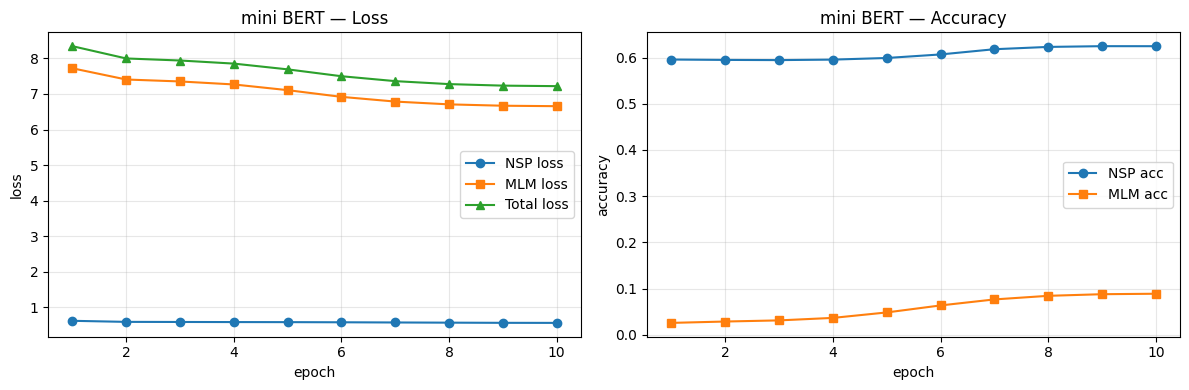

figure: /content/models/mini_bert_train_curves.png
params: 1,455,104
final: {'nsp_loss': 0.5633832694292068, 'mlm_loss': 6.657316542387009, 'nsp_acc': 0.624609375, 'mlm_acc': 0.08885967785120011, 'loss': 7.220699811697006}
Drive 백업: /content/drive/MyDrive/AIFFEL/LLM01/mini_bert_train_curves.png


In [11]:
# =============================================================================
# 7) 학습 곡선 시각화 (루브릭: MLM/NSP 감소 확인 + 결과 이미지 제출)
# =============================================================================
if not history.get("loss"):
    ckpt_files = sorted(MODEL_DIR.glob("mini_bert_epoch_*.pt"), key=lambda x: x.stat().st_mtime)
    if not ckpt_files and USE_DRIVE and DRIVE_DIR is not None:
        ckpt_files = sorted(DRIVE_DIR.glob("mini_bert_epoch_*.pt"), key=lambda x: x.stat().st_mtime)
    if ckpt_files:
        ckpt = torch.load(ckpt_files[-1], map_location="cpu", weights_only=False)
        history = ckpt.get("history", history)
        n_params = ckpt.get("n_params", n_params if "n_params" in dir() else 0)
        print("history restored from", ckpt_files[-1])

epochs_x = list(range(1, len(history["loss"]) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_x, history["nsp_loss"], "o-", label="NSP loss")
axes[0].plot(epochs_x, history["mlm_loss"], "s-", label="MLM loss")
axes[0].plot(epochs_x, history["loss"], "^-", label="Total loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("mini BERT — Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, history["nsp_acc"], "o-", label="NSP acc")
axes[1].plot(epochs_x, history["mlm_acc"], "s-", label="MLM acc")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("mini BERT — Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = MODEL_DIR / "mini_bert_train_curves.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("figure:", fig_path)
print("params:", f"{n_params:,}" if "n_params" in dir() else "?")
print("final:", {k: history[k][-1] for k in history} if history.get("loss") else {})
backup_to_drive(fig_path)
sync_all_to_drive()


## 회고

### 실험 환경·설정
- Colab GPU: **Tesla T4**, torch `2.11.0+cu128`
- mini BERT: `d_model=128`, `n_layer=2`, `n_head=4`, `d_ff=512`, `n_seq=128`
- **trainable params = 1,455,104 (≈1.46M)** → 루브릭(~1M) 충족
- 데이터: SentencePiece vocab=8000(+특수토큰), MLM 15%(80/10/10), NSP≈50%, `COUNT=128000`, 10 epoch

### 실제 학습 결과 (10 epoch)

| Epoch | Total loss | NSP loss | MLM loss | NSP acc | MLM acc |
|------:|----------:|---------:|---------:|--------:|--------:|
| 1 | 8.3450 | 0.6218 | 7.7231 | 0.5957 | 0.0258 |
| 5 | 7.6928 | 0.5844 | 7.1083 | 0.5991 | 0.0484 |
| 10 | 7.2207 | 0.5634 | 6.6573 | 0.6246 | 0.0889 |

- **Total / MLM / NSP loss 모두 epoch 1→10에서 단조 감소** (루브릭: 안정적 감소 확인)
- NSP acc: 0.60 → 0.62 (랜덤 0.5 대비 우위)
- MLM acc: 0.026 → 0.089 (vocab=8007 Softmax라 절대값은 낮지만 **상승 추세**는 분명)
- 후반(ep8→10) loss 감소폭이 작아짐 → cosine schedule 말미 + mini 모델 용량 한계로 **완만한 수렴 구간**에 진입

### Colab 끊김·백업
- `ensure_gpu` / 에폭 ckpt / **생성 산출물 전체 Drive 자동 백업·복원**으로 `/content` 휘발성에 대응
- 백업 대상: `kowiki.*`, `ko_8000.*`, `bert_pre_train.json`, memmap 4종, `mini_bert_epoch_*.pt`, `mini_bert_train_curves.png`

### 배운 점 / 아쉬운 점
- **배운 점**: BERT pretrain 파이프라인(SPM → MLM/NSP json → memmap → Encoder-only)을 end-to-end로 돌려 보며, loss 합산·ignore_index·segment embedding 역할을 체감했다. Drive 동기화로 Colab 세션 단절 비용을 크게 줄일 수 있었다.
- **아쉬운 점**: MLM acc가 여전히 낮은 편이고, `COUNT=128000`·짧은 seq로 용량/데이터 스케일을 제한했다. 여유 GPU 시간이 있으면 epoch 추가나 COUNT 상향을 다음에 시도하고 싶다.

### 실행 플로우
```
kowiki 다운로드 → SPM(8000) → MLM/NSP json → memmap
       → mini BERT(~1.46M) → 10 epoch Adam+Cosine
       → curves.png + epoch.pt  (전부 Drive 동기화)
```

### 참고
- Devlin et al., *BERT: Pre-training of Deep Bidirectional Transformers* (2018)
- AIFFEL LMS — BERT pretrained model / mini BERT 프로젝트
